# Temperature Prediction — Nuclear Waste Storage Tunnel

### **Group**: 12
### **Authors**: Anna Billon, Eva Kupecek

In [21]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.neighbors import KDTree

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print('Imports OK.')

Imports OK.


In [22]:
# Data paths
REPO_ROOT = Path('.').resolve()

for _candidate in [
    REPO_ROOT / 'data_parquet_2026' / 'data_parquet_2026',
    REPO_ROOT / 'data_parquet_2026',
]:
    if (_candidate / 'train.parquet').exists():
        RAW_DIR = _candidate
        break

PROCESSED_DIR   = REPO_ROOT / 'data' / 'processed'
SUBMISSIONS_DIR = REPO_ROOT / 'submissions'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

SECONDS_PER_YEAR = 365.25 * 24 * 3600
RANDOM_STATE     = 42
TARGET           = 'temperature'

# Load raw files
train_raw = pd.read_parquet(RAW_DIR / 'train.parquet')
test_raw  = pd.read_parquet(RAW_DIR / 'test.parquet')
sensors   = pd.read_parquet(RAW_DIR / 'sensors.parquet')

# Merge 3D coordinates into train and test
sensors_unique = sensors.groupby('sensor', as_index=False).mean(numeric_only=True)
train_raw = train_raw.merge(sensors_unique, on='sensor', how='left')
test_raw  = test_raw.merge(sensors_unique,  on='sensor', how='left')

print(f'train : {train_raw.shape}')
print(f'test  : {test_raw.shape}')
print(f'\nTrain columns : {train_raw.columns.tolist()}')
train_raw.head(3)

train : (6626928, 7)
test  : (2190480, 6)

Train columns : ['sensor', 'time', 'power', 'temperature', 'coor_x', 'coor_y', 'coor_z']


,sensor,time,power,temperature,coor_x,coor_y,coor_z
0,N102,0.0,1487.964722,17.514429,46.131474,3.5,0.0
1,N102,864000.0,1487.288818,17.820795,46.131474,3.5,0.0
2,N102,1728000.0,1486.612915,17.573187,46.131474,3.5,0.0


## 1. Data Cleaning

Four cascaded filters remove physically impossible or corrupted readings:

| Step | Filter | Threshold |
|------|--------|-----------|
| 1 | Physical limits | [0, 200] °C |
| 2 | IQR per sensor | 4 × IQR |
| 3 | Temporal spikes | rolling window = 21, robust z > 8 σ |
| 4 | Failed sensors | > 20% bad readings excluded |

Physical limits are applied first so extreme values (e.g. −9999 °C) don't inflate the IQR and hide moderate outliers. Thresholds are intentionally permissive — better to keep a borderline value than discard a genuine physical extreme.

In [23]:
# Cleaning thresholds — conservative values to avoid removing genuine extreme temperatures
TEMP_MIN         = 0.0    # below 0°C = physically impossible in this tunnel
TEMP_MAX         = 200.0  # above 200°C = unrealistic for this experiment
IQR_MULTIPLIER   = 4.0    # 4× IQR instead of standard 1.5× to keep genuine extremes
ROLLING_WINDOW   = 21     # ~21 timesteps window for spike detection
ROLLING_Z_LIMIT  = 8.0    # robust z-score threshold: only flag clear anomalies
MAX_BAD_FRACTION = 0.20   # exclude sensors with >20% bad readings

**Step 1–3 — Flag bad rows.** Each filter adds a boolean column without removing any data yet. This lets us count and visualise each type of anomaly separately before discarding anything.

In [24]:
def create_cleaning_flags(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds flag columns (True = bad row). Four cascaded filters applied in order:
      flag_physical : temperature outside [0, 200] °C
      flag_iqr      : IQR outlier per sensor (4×), computed on physically valid rows only
      flag_spike    : isolated temporal spike (robust z-score on rolling window)
      flag_bad      : union of all flags above + missing values
    """
    df = df.copy()

    # 1 — Physical limits (applied first to avoid contaminating IQR stats)
    df['flag_missing']  = df['temperature'].isna()
    df['flag_physical'] = (df['temperature'].notna()
                           & ((df['temperature'] < TEMP_MIN) | (df['temperature'] > TEMP_MAX)))

    # 2 — IQR per sensor (each sensor has its own thermal range)
    valid = df['temperature'].notna() & ~df['flag_physical']
    q1 = df.loc[valid].groupby('sensor', observed=True)['temperature'].quantile(0.25)
    q3 = df.loc[valid].groupby('sensor', observed=True)['temperature'].quantile(0.75)
    iqr = q3 - q1
    bounds = pd.DataFrame({'sensor': q1.index,
                           'lower': (q1 - IQR_MULTIPLIER * iqr).values,
                           'upper': (q3 + IQR_MULTIPLIER * iqr).values})
    df = df.merge(bounds, on='sensor', how='left', validate='many_to_one')
    df['flag_iqr'] = (valid & df['lower'].notna()
                      & ((df['temperature'] < df['lower']) | (df['temperature'] > df['upper'])))
    df.drop(columns=['lower', 'upper'], inplace=True)

    # 3 — Temporal spikes: robust z-score (MAD-based) on a rolling median
    df = df.sort_values(['sensor', 'time']).reset_index(drop=True)
    rolling_med = (df.groupby('sensor', observed=True)['temperature']
                   .transform(lambda s: s.rolling(ROLLING_WINDOW, center=True, min_periods=5).median()))
    residual = df['temperature'] - rolling_med
    mad      = residual.abs().groupby(df['sensor'], observed=True).transform('median')
    robust_z = residual.abs() / (1.4826 * mad + 1e-6)
    df['flag_spike'] = (df['temperature'].notna() & rolling_med.notna() & (robust_z > ROLLING_Z_LIMIT))

    df['flag_bad'] = df['flag_missing'] | df['flag_physical'] | df['flag_iqr'] | df['flag_spike']
    return df

print('create_cleaning_flags defined.')

create_cleaning_flags defined.


**Step 4 — Identify and remove.** Sensors with more than 20% bad readings are excluded entirely (they contribute more noise than signal). Then all flagged rows are dropped.

In [25]:
def identify_failed_sensors(flagged: pd.DataFrame) -> set:
    """Returns sensors where >20% of readings are flagged as bad."""
    stats = flagged.groupby('sensor', observed=True)['flag_bad'].agg(['sum', 'count'])
    stats['bad_frac'] = stats['sum'] / stats['count']
    return set(stats[stats['bad_frac'] > MAX_BAD_FRACTION].index.astype(str))

def clean_train_data(flagged: pd.DataFrame, failed_sensors: set) -> pd.DataFrame:
    """Remove bad rows and failed sensors; drop flag columns."""
    flag_cols = [c for c in flagged.columns if c.startswith('flag_')]
    return (flagged
            .loc[~flagged['flag_bad']]
            .loc[~flagged['sensor'].astype(str).isin(failed_sensors)]
            .drop(columns=flag_cols)
            .reset_index(drop=True))

print('identify_failed_sensors, clean_train_data defined.')

identify_failed_sensors, clean_train_data defined.


Cleaning in progress...

  Original rows             :  6,626,928
  Missing temperatures      :     99,403
  Outside physical limits   :    189,900
  IQR outliers              :      8,819
  Temporal spikes           :     40,808
  Failed sensors            :         10
  ----------------------------------------
  Removed rows (total)      :    446,267  (6.7%)
  Cleaned rows              :  6,180,661
  Active sensors            :        232


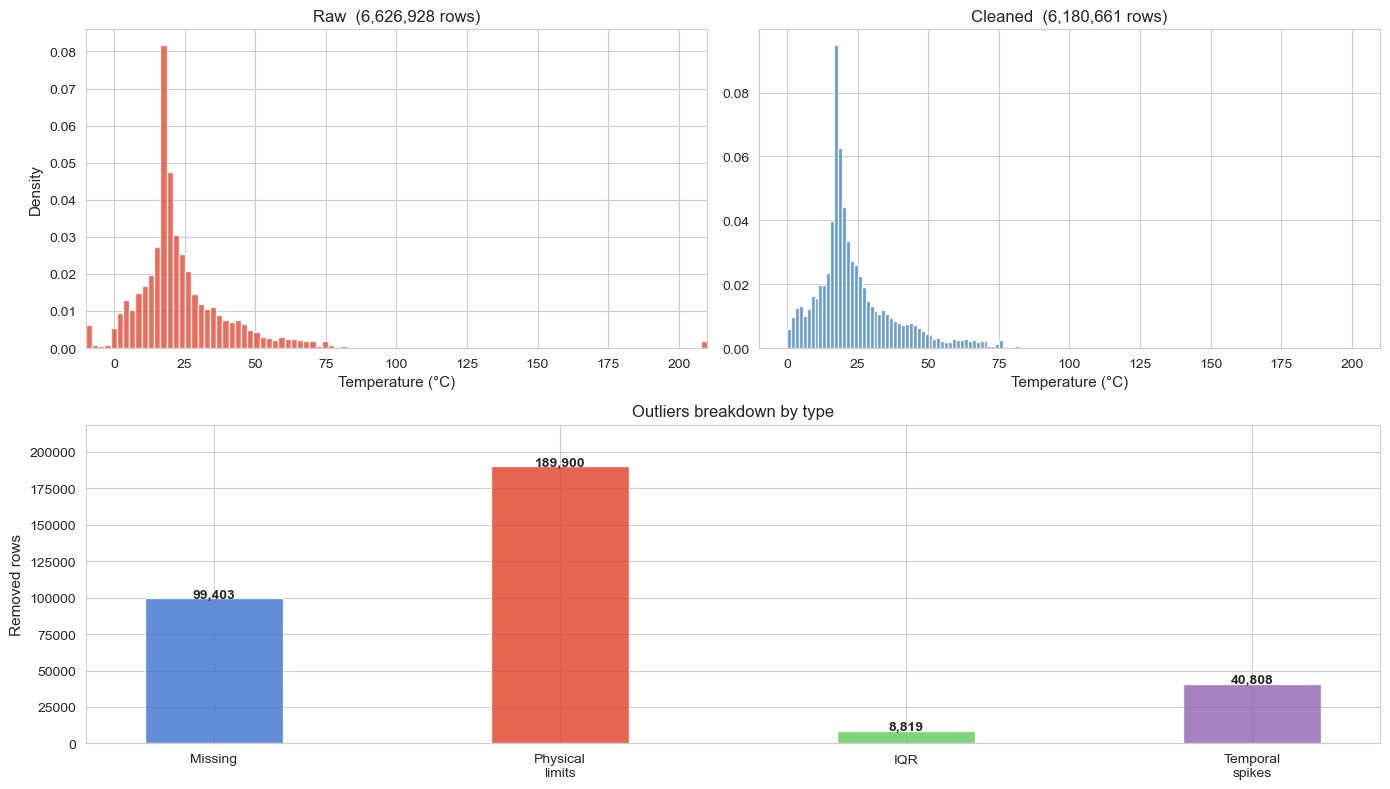

In [26]:
# Run cleaning
print('Cleaning in progress...')
flagged        = create_cleaning_flags(train_raw)
failed_sensors = identify_failed_sensors(flagged)
train_cleaned  = clean_train_data(flagged, failed_sensors)

n_removed = len(train_raw) - len(train_cleaned)
print(f"\n{'='*52}")
print(f'  Original rows             : {len(train_raw):>10,}')
print(f'  Missing temperatures      : {flagged["flag_missing"].sum():>10,}')
print(f'  Outside physical limits   : {flagged["flag_physical"].sum():>10,}')
print(f'  IQR outliers              : {flagged["flag_iqr"].sum():>10,}')
print(f'  Temporal spikes           : {flagged["flag_spike"].sum():>10,}')
print(f'  Failed sensors            : {len(failed_sensors):>10}')
print(f'  ----------------------------------------')
print(f'  Removed rows (total)      : {n_removed:>10,}  ({n_removed/len(train_raw):.1%})')
print(f'  Cleaned rows              : {len(train_cleaned):>10,}')
print(f'  Active sensors            : {train_cleaned["sensor"].nunique():>10}')
print(f"{'='*52}")

fig = plt.figure(figsize=(14, 8))
plot_range = (-10, 210)

# Row 1 — Raw (left) + Cleaned (right)
ax1 = fig.add_subplot(2, 2, 1)
raw_clipped = flagged['temperature'].dropna().clip(*plot_range)
ax1.hist(raw_clipped, bins=100, color='#E24A33', alpha=0.8, density=True)
ax1.set_xlim(plot_range)
ax1.set_xlabel('Temperature (°C)', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.set_title(f'Raw  ({len(train_raw):,} rows)', fontsize=12)

ax2 = fig.add_subplot(2, 2, 2)
cleaned_clipped = train_cleaned['temperature'].clip(*plot_range)
ax2.hist(cleaned_clipped, bins=100, color='steelblue', alpha=0.8, density=True)
ax2.set_xlim(plot_range)
ax2.set_xlabel('Temperature (°C)', fontsize=11)
ax2.set_title(f'Cleaned  ({len(train_cleaned):,} rows)', fontsize=12)

# Row 2 — Outliers breakdown (spanning full width)
ax3 = fig.add_subplot(2, 1, 2)
counts = {
    'Missing':          int(flagged['flag_missing'].sum()),
    'Physical\nlimits': int(flagged['flag_physical'].sum()),
    'IQR':              int(flagged['flag_iqr'].sum()),
    'Temporal\nspikes': int(flagged['flag_spike'].sum()),
}
bar_colors = ['#4878CF', '#E24A33', '#6ACC65', '#956CB4']
bars = ax3.bar(counts.keys(), counts.values(), color=bar_colors, alpha=0.85, width=0.4)
ax3.set_ylabel('Removed rows', fontsize=11)
ax3.set_title('Outliers breakdown by type', fontsize=12)
for bar, v in zip(bars, counts.values()):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{v:,}', ha='center', fontsize=10, fontweight='bold')
ax3.set_ylim(0, max(counts.values()) * 1.15)

plt.tight_layout()
plt.show()

**Physical limits (dominant category):** a subset of sensors occasionally report sentinel failure values far outside any physical range. Removing these first prevents them from contaminating the IQR statistics.  
**Temporal spikes:** brief isolated anomalies — instrument glitches, not physical events.  
**IQR outliers:** smallest category — moderate values that fall outside each sensor's expected range after gross failures are already removed.

## 2. Feature Engineering

3 features are engineered from the raw columns (`time`, `power`, `coor_x`, `coor_y`):

| Feature | Formula | Physical meaning |
|---|---|---|
| `r_xy` | `√(x² + y²)` | 2D radial distance to canister |
| `power_x_time` | `power × time_years` | Cumulative energy proxy |
| `power_over_r_xy` | `power / r_xy` | Heat flux proxy (highest importance) |

Excluded features: `coor_z` (all sensors have `coor_z = 0`, 2D geometry).

**Buffer/OPA boundary:** vertical line at `coor_x = 1.4 m`. Sensors with `coor_x > 1.4 m` are in OPA (Opalinus Clay).

Features added. Train shape: (6180661, 10)


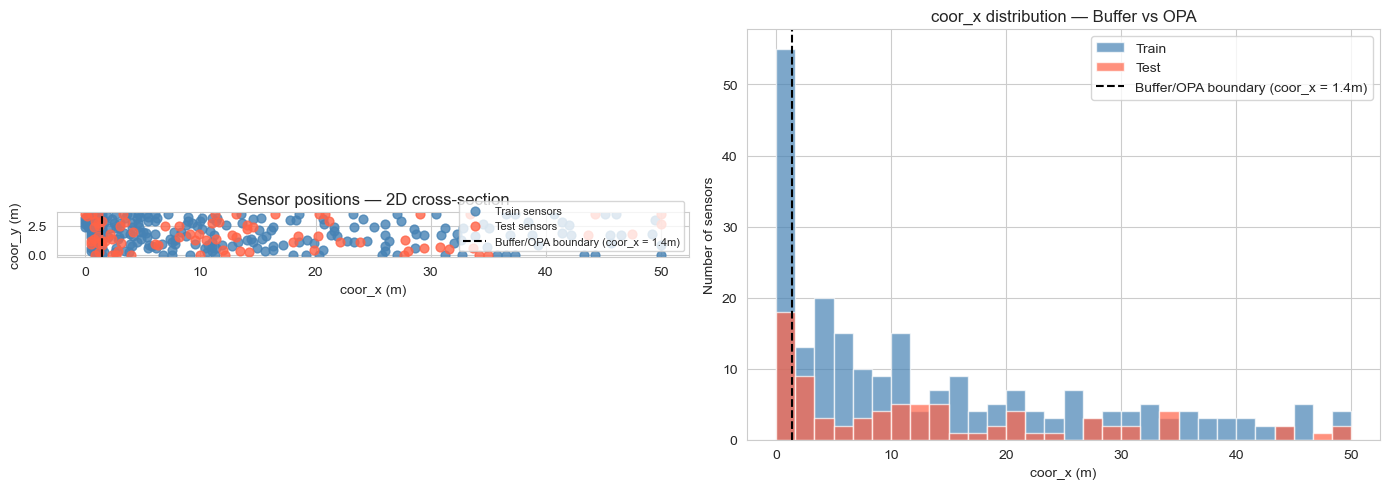

In [27]:
def add_base_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add engineered features to train or test dataframe."""
    df = df.copy()
    df['r_xy']            = np.sqrt(df['coor_x']**2 + df['coor_y']**2)
    df['power_x_time']    = df['power'] * df['time'] / (365.25 * 24 * 3600)
    df['power_over_r_xy'] = df['power'] / (df['r_xy'] + 1e-9)
    return df

train_cleaned = add_base_features(train_cleaned)
test_feat     = add_base_features(test_raw)

print(f"Features added. Train shape: {train_cleaned.shape}")

# Sensor geometry visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sensors_train = train_cleaned.groupby('sensor')[['coor_x', 'coor_y']].mean()
sensors_test  = test_feat.groupby('sensor')[['coor_x', 'coor_y']].mean()

ax = axes[0]
ax.scatter(sensors_train['coor_x'], sensors_train['coor_y'], c='steelblue', s=40, label='Train sensors', alpha=0.8)
ax.scatter(sensors_test['coor_x'],  sensors_test['coor_y'],  c='tomato',    s=40, label='Test sensors',  alpha=0.8)
ax.axvline(x=1.4, color='black', linestyle='--', linewidth=1.5, label='Buffer/OPA boundary (coor_x = 1.4m)')
ax.set_aspect('equal'); ax.set_xlabel('coor_x (m)'); ax.set_ylabel('coor_y (m)')
ax.set_title('Sensor positions — 2D cross-section'); ax.legend(fontsize=8)

ax = axes[1]
ax.hist(sensors_train['coor_x'], bins=30, color='steelblue', alpha=0.7, label='Train')
ax.hist(sensors_test['coor_x'],  bins=30, color='tomato',    alpha=0.7, label='Test')
ax.axvline(1.4, color='black', linestyle='--', label='Buffer/OPA boundary (coor_x = 1.4m)')
ax.set_xlabel('coor_x (m)'); ax.set_ylabel('Number of sensors')
ax.set_title('coor_x distribution — Buffer vs OPA'); ax.legend()

plt.tight_layout()
plt.show()

The tunnel is strongly elongated: sensors span ~50 m along `coor_x` but only ~3 m along `coor_y`. The Buffer zone (left of the dashed line) contains only a handful of very hot sensors near the canister. Most sensors are in OPA, where temperatures are lower and gradients are smaller — this is where prediction error is highest. Test sensors (red) cover the full range of `coor_x`, requiring the model to generalise across both zones.

## 3. Model Architecture

The problem is **spatial interpolation**: at each timestep, temperatures are known at 222 train sensors — we must predict temperatures at 80 unseen positions. We compute spatial summary features from the known sensor field and let HistGB learn the residual corrections.

---

### 3.1 IDW — Inverse Distance Weighting (main spatial feature)

At each timestep t, IDW estimates the temperature at query position j as a distance-weighted average over all source sensors:

$$T_{\text{IDW}}(j, t) = \frac{\sum_i T_i(t) / d(j,i)^2}{\sum_i 1 / d(j,i)^2}$$

IDW is physically motivated and parameter-free. It is passed as a **feature** to HistGB — alone it has no knowledge of time or material properties, but HistGB learns to correct its biases. Global IDW (all 222 sensors): global averaging produces a more stable spatial prior.

---

### 3.2 Complementary spatial and temporal features

| Feature | Description |
|---|---|
| `nn_temp`, `nn_dist` | Temperature and distance of the closest train sensor |
| `broad_temp_mean`, `broad_temp_std` | Mean and std of the 5 nearest sensors |
| `nn_dtdt` | Rate of temperature change (°C/s) of the nearest neighbour, estimated by sliding-window linear regression |

---

### 3.3 HistGradientBoostingRegressor

HistGB learns to predict temperature directly from all 13 features. It handles mixed scales, captures non-linear interactions, and stops early when validation loss plateaus.

**Validation — sensor-level split (80/20):** entire sensors are held out, preventing spatial leakage through IDW/KNN lookups.

| Set | Sensors | Rows |
|---|---|---|
| Training | ~185 | ~4,930,000 |
| Validation | ~47 | ~1,250,000 |

In [28]:
# Features and model hyperparameters
K_BROAD     = 5      # number of nearest neighbours for broad spatial features
IDW_POWER   = 2      # IDW weight = 1 / distance^IDW_POWER
GRAD_WINDOW = 10     # window size for temporal gradient dT/dt estimation
TARGET      = 'temperature'
BUFFER_X    = 1.4    # Buffer/OPA boundary: vertical line at coor_x = 1.4m

# Excluded: coor_z, r_xyz (coor_z = 0 for all sensors), abs_y, time_years (importance = 0)
BASE_FEATURES    = ['time','power','coor_x','coor_y',
                    'r_xy','power_x_time','power_over_r_xy']
IDW_FEATURES     = ['idw_temp']
SPATIAL_FEATURES = ['nn_temp','nn_dist','broad_temp_mean','broad_temp_std']
GRAD_FEATURES    = ['nn_dtdt']
ALL_FEATURES     = BASE_FEATURES + IDW_FEATURES + SPATIAL_FEATURES + GRAD_FEATURES

# HistGradientBoosting — early stopping on 10% internal validation
MODEL_PARAMS = dict(
    loss='squared_error', learning_rate=0.05, max_iter=500,
    max_leaf_nodes=63, l2_regularization=0.01,
    early_stopping=True, validation_fraction=0.10,
    random_state=RANDOM_STATE,
)

print(f'Total features: {len(ALL_FEATURES)} — {ALL_FEATURES}')

Total features: 13 — ['time', 'power', 'coor_x', 'coor_y', 'r_xy', 'power_x_time', 'power_over_r_xy', 'idw_temp', 'nn_temp', 'nn_dist', 'broad_temp_mean', 'broad_temp_std', 'nn_dtdt']


**Sensor-level split.** Entire sensors are held out — no individual rows from a validation sensor appear in training. This prevents any spatial leakage through the IDW/KNN features.

In [29]:
def sensor_split(df):
    """80/20 split at the sensor level — whole sensors go to train or val, never split."""
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
    idx_tr, idx_val = next(splitter.split(df, groups=df['sensor']))
    return df.iloc[idx_tr].copy(), df.iloc[idx_val].copy()

print('sensor_split defined.')

sensor_split defined.


**KNN hybrid features.** For each query sensor, find the k nearest source sensors using a KD-tree. Then look up each neighbour's temperature at the closest available timestep to produce `nn_temp`, `nn_dist`, `broad_temp_mean`, `broad_temp_std`.

In [30]:
def build_neighbor_map(query_sensors, source_sensors, k):
    """KD-tree: returns k nearest source sensors for each query sensor (self excluded)."""
    coord_cols = ['coor_x','coor_y','coor_z']
    source_u = source_sensors.groupby('sensor')[coord_cols].mean()
    query_u  = query_sensors.groupby('sensor')[coord_cols].mean()
    tree = KDTree(source_u[coord_cols].values)
    dists, idxs = tree.query(query_u[coord_cols].values, k=k+1)
    src_index = source_u.index.tolist()
    rows = []
    for i, sensor in enumerate(query_u.index):
        rank = 0
        for dist, idx in zip(dists[i], idxs[i]):
            neighbor = src_index[idx]
            if neighbor == sensor: continue
            rows.append({'sensor': sensor, 'neighbor_sensor': neighbor,
                         'neighbor_dist': dist, 'neighbor_rank': rank})
            rank += 1
            if rank >= k: break
    return pd.DataFrame(rows)

def build_temp_lookup(source):
    """Index each source sensor's temperature series by time for fast O(log n) lookup."""
    return {
        sensor: grp.set_index('time')['temperature'].sort_index()
                   .pipe(lambda s: s[~s.index.duplicated(keep='first')])
        for sensor, grp in source.groupby('sensor', observed=True)
    }

def expand_neighbors(df, neighbor_map, temp_lookup):
    """For each (row, neighbour) pair, look up the neighbour temperature at the nearest timestep."""
    expanded = (df[['sensor','time']].reset_index(names='row_idx')
                .merge(neighbor_map, on='sensor', how='left'))
    parts = []
    for nbr, grp in expanded.groupby('neighbor_sensor', observed=True):
        series = temp_lookup.get(nbr)
        if series is None or series.empty:
            grp = grp.copy(); grp['neighbor_temp'] = np.nan; parts.append(grp); continue
        times = grp['time'].values; sorted_t = series.index.values
        idxs  = np.clip(np.searchsorted(sorted_t, times), 0, len(sorted_t)-1)
        prev  = np.clip(idxs-1, 0, len(sorted_t)-1)
        use_prev = np.abs(sorted_t[prev]-times) < np.abs(sorted_t[idxs]-times)
        grp = grp.copy()
        grp['neighbor_temp'] = series.iloc[np.where(use_prev, prev, idxs)].values
        parts.append(grp)
    return pd.concat(parts, ignore_index=True)

def compute_hybrid_features(df, expanded):
    """Aggregate neighbour temperatures into nn_temp/nn_dist (k=1) and broad mean/std (k=5)."""
    near = (expanded[expanded['neighbor_rank']==0]
            [['row_idx','neighbor_temp','neighbor_dist']]
            .rename(columns={'neighbor_temp':'nn_temp','neighbor_dist':'nn_dist'})
            .set_index('row_idx'))
    broad = (expanded[expanded['neighbor_rank'] < K_BROAD]
             .groupby('row_idx')
             .agg(broad_temp_mean=('neighbor_temp','mean'),
                  broad_temp_std =('neighbor_temp','std')))
    return df.reset_index(drop=True).join(near).join(broad)

print('KNN functions defined.')

KNN functions defined.


**Temporal gradient dT/dt.** For each source sensor, fit a local linear regression over a sliding window of `GRAD_WINDOW` timesteps to estimate the instantaneous rate of temperature change at each point in time. Then, for each query row, look up the dT/dt of its single nearest neighbour at the closest available timestep.

In [31]:
def build_dtdt_lookup(source, window=GRAD_WINDOW):
    """
    For each source sensor, estimate dT/dt at every timestep via sliding-window
    linear regression. Returns dict: sensor -> Series(time -> dT/dt in °C/s).
    """
    lookup = {}
    for sensor, grp in source.groupby('sensor', observed=True):
        series = (grp.set_index('time')['temperature'].sort_index()
                  .pipe(lambda s: s[~s.index.duplicated(keep='first')]))
        times = series.index.values.astype(np.float64)
        temps = series.values.astype(np.float64)
        n = len(times)
        dtdt = np.full(n, np.nan)
        for i in range(n):
            lo = max(0, i - window // 2)
            hi = min(n, i + window // 2 + 1)
            if hi - lo < 2:
                continue
            t_w = times[lo:hi]; T_w = temps[lo:hi]
            t_c = t_w - t_w.mean(); denom = (t_c ** 2).sum()
            if denom == 0:
                continue
            dtdt[i] = (t_c * T_w).sum() / denom
        lookup[sensor] = pd.Series(dtdt, index=series.index)
    return lookup


def compute_dtdt_feature(df, neighbor_map, dtdt_lookup):
    """
    Adds nn_dtdt: dT/dt of the single nearest neighbour (rank=0)
    looked up at the closest available timestep.
    """
    nn_map = neighbor_map[neighbor_map['neighbor_rank'] == 0][['sensor', 'neighbor_sensor']]
    expanded = (df[['sensor', 'time']].reset_index(names='row_idx')
                .merge(nn_map, on='sensor', how='left'))
    parts = []
    for nbr, grp in expanded.groupby('neighbor_sensor', observed=True):
        series = dtdt_lookup.get(nbr)
        if series is None or series.empty:
            grp = grp.copy(); grp['nn_dtdt'] = np.nan; parts.append(grp); continue
        times = grp['time'].values; sorted_t = series.index.values
        idxs  = np.clip(np.searchsorted(sorted_t, times), 0, len(sorted_t) - 1)
        prev  = np.clip(idxs - 1, 0, len(sorted_t) - 1)
        use_prev = np.abs(sorted_t[prev] - times) < np.abs(sorted_t[idxs] - times)
        grp = grp.copy()
        grp['nn_dtdt'] = series.iloc[np.where(use_prev, prev, idxs)].values
        parts.append(grp)
    dtdt_df = pd.concat(parts, ignore_index=True).set_index('row_idx')[['nn_dtdt']]
    return df.reset_index(drop=True).join(dtdt_df)

print('build_dtdt_lookup, compute_dtdt_feature defined.')

build_dtdt_lookup, compute_dtdt_feature defined.


**IDW feature.** Builds a distance-weight matrix (query sensors × source sensors) once, then iterates over unique timesteps to compute the weighted average temperature at each query position. Self-contribution is excluded when a sensor appears in both query and source sets.

In [32]:
from sklearn.metrics.pairwise import euclidean_distances

def compute_idw_feature(df, query_coords, source_coords, source_data, power=IDW_POWER):
    """
    Adds idw_temp: T_idw(j,t) = Σ T_i(t)/d² / Σ 1/d²  over all source sensors.
    Weight matrix is precomputed (constant across time) — only the temperature
    vector changes per timestep, keeping memory usage O(n_sensors²).
    """
    coord_cols = ['coor_x','coor_y','coor_z']
    query_u  = query_coords.groupby('sensor')[coord_cols].mean()
    source_u = source_coords.groupby('sensor')[coord_cols].mean()
    q_list, s_list = query_u.index.tolist(), source_u.index.tolist()

    # Precompute weight matrix — shape (n_query_sensors × n_source_sensors)
    dist_mat = euclidean_distances(query_u[coord_cols].values, source_u[coord_cols].values)
    s_idx_map = {s: j for j, s in enumerate(s_list)}
    for i, q in enumerate(q_list):
        if q in s_idx_map: dist_mat[i, s_idx_map[q]] = np.inf  # exclude self
    weights_mat = 1.0 / (dist_mat**power + 1e-9)

    # Pivot source temperatures: shape (n_timesteps × n_source_sensors)
    q_idx_map = {s: i for i, s in enumerate(q_list)}
    source_pivot = (source_data.groupby(['time','sensor'])['temperature']
                    .mean().unstack('sensor').reindex(columns=s_list))
    pivot_times, pivot_vals = source_pivot.index.values, source_pivot.values

    df = df.reset_index(drop=True)
    df_times = df['time'].values
    df_q_idx = df['sensor'].map(q_idx_map).values
    t_idxs = np.clip(np.searchsorted(pivot_times, df_times), 0, len(pivot_times)-1)
    t_prev = np.clip(t_idxs-1, 0, len(pivot_times)-1)
    use_prev = np.abs(pivot_times[t_prev]-df_times) < np.abs(pivot_times[t_idxs]-df_times)
    t_idxs = np.where(use_prev, t_prev, t_idxs)

    # Loop over unique timesteps (avoids loading all data at once)
    idw_values = np.full(len(df), np.nan, dtype=np.float64)
    for t_uniq in np.unique(t_idxs):
        mask = t_idxs == t_uniq
        src_temps = pivot_vals[t_uniq, :]; valid = ~np.isnan(src_temps)
        if not valid.any(): continue
        row_w = weights_mat[df_q_idx[mask], :]; w_valid = row_w * valid
        denom = w_valid.sum(axis=1)
        numer = (w_valid * np.where(valid, src_temps, 0.0)).sum(axis=1)
        idw_values[mask] = np.where(denom > 0, numer/denom, np.nan)

    df = df.copy(); df['idw_temp'] = idw_values
    return df

print('compute_idw_feature defined.')

compute_idw_feature defined.


In [33]:
# Split data and build coordinate tables used by IDW and KNN
train_part, val_part = sensor_split(train_cleaned)
print(f'Train: {train_part["sensor"].nunique()} sensors | {len(train_part):,} rows')
print(f'Val  : {val_part["sensor"].nunique()} sensors  | {len(val_part):,} rows')

train_coords     = train_part[['sensor','coor_x','coor_y','coor_z']].drop_duplicates('sensor')
all_train_coords = train_cleaned[['sensor','coor_x','coor_y','coor_z']].drop_duplicates('sensor')
val_coords       = val_part[['sensor','coor_x','coor_y','coor_z']].drop_duplicates('sensor')
test_coords      = test_feat[['sensor','coor_x','coor_y','coor_z']].drop_duplicates('sensor')

Train: 185 sensors | 4,930,181 rows
Val  : 47 sensors  | 1,250,480 rows


**Compute KNN features.** Build neighbour maps (KD-tree, fixed geometry) then look up temperatures at each timestep. NaN filled with median (rare edge cases where a neighbour has no data at a given time).

In [34]:
print('Computing KNN hybrid features...')
nm_train = build_neighbor_map(train_coords, train_coords, K_BROAD)
nm_val   = build_neighbor_map(val_coords,   train_coords, K_BROAD)
nm_test  = build_neighbor_map(test_coords,  all_train_coords, K_BROAD)

lookup_train = build_temp_lookup(train_part)
lookup_all   = build_temp_lookup(train_cleaned)

train_part = compute_hybrid_features(train_part, expand_neighbors(train_part, nm_train, lookup_train))
val_part   = compute_hybrid_features(val_part,   expand_neighbors(val_part,   nm_val,   lookup_train))
test_feat  = compute_hybrid_features(test_feat,  expand_neighbors(test_feat,  nm_test,  lookup_all))

for col in SPATIAL_FEATURES:
    med = train_part[col].median()
    train_part[col] = train_part[col].fillna(med)
    val_part[col]   = val_part[col].fillna(med)
    test_feat[col]  = test_feat[col].fillna(med)

print('KNN features done.')

Computing KNN hybrid features...
KNN features done.


**Compute dT/dt feature.** Build the gradient lookup for each source sensor (one linear regression per sensor per timestep window), then attach `nn_dtdt` to each row via the nearest-neighbour map. NaN values (edges of time series or sensors with too few points) are filled with the median.

In [35]:
print(f'Computing temporal gradient feature (window={GRAD_WINDOW})...')
dtdt_train = build_dtdt_lookup(train_part)
dtdt_all   = build_dtdt_lookup(train_cleaned)

train_part = compute_dtdt_feature(train_part, nm_train, dtdt_train)
val_part   = compute_dtdt_feature(val_part,   nm_val,   dtdt_train)
test_feat  = compute_dtdt_feature(test_feat,  nm_test,  dtdt_all)

dtdt_med = train_part['nn_dtdt'].median()
train_part['nn_dtdt'] = train_part['nn_dtdt'].fillna(dtdt_med)
val_part['nn_dtdt']   = val_part['nn_dtdt'].fillna(dtdt_med)
test_feat['nn_dtdt']  = test_feat['nn_dtdt'].fillna(dtdt_med)

print('dT/dt feature done.')

Computing temporal gradient feature (window=10)...
dT/dt feature done.


**Compute IDW feature.** The weight matrix is built once per split (geometry is fixed), then applied across all ~9000 timesteps. This is the most compute-intensive step (~15–20 min total).

In [36]:
print('Computing IDW feature (global, all source sensors)...')
train_part = compute_idw_feature(train_part, train_coords, train_coords, train_part)
val_part   = compute_idw_feature(val_part,   val_coords,   train_coords, train_part)
test_feat  = compute_idw_feature(test_feat,  test_coords,  all_train_coords, train_cleaned)

idw_med = train_part['idw_temp'].median()
train_part['idw_temp'] = train_part['idw_temp'].fillna(idw_med)
val_part['idw_temp']   = val_part['idw_temp'].fillna(idw_med)
test_feat['idw_temp']  = test_feat['idw_temp'].fillna(idw_med)

features = [f for f in ALL_FEATURES if f in train_part.columns and f in test_feat.columns]
print(f'IDW done. Total features: {len(features)}')

Computing IDW feature (global, all source sensors)...
IDW done. Total features: 13


**Train HistGradientBoosting and evaluate on validation sensors.**

In [37]:
print('Training HistGradientBoosting...')
model = HistGradientBoostingRegressor(**MODEL_PARAMS)
model.fit(train_part[features], train_part[TARGET])

val_pred = model.predict(val_part[features])
y_val    = val_part[TARGET].values

rmse = float(np.sqrt(mean_squared_error(y_val, val_pred)))
mae  = float(mean_absolute_error(y_val, val_pred))
r2   = float(r2_score(y_val, val_pred))

print(f'\nValidation ({val_part["sensor"].nunique()} unseen sensors):')
print(f'  RMSE : {rmse:.5f}')
print(f'  MAE  : {mae:.5f}')
print(f'  R²   : {r2:.5f}')

# RMSE breakdown by zone
val_opa = val_part['coor_x'].values > BUFFER_X
for zone, mask in [('Buffer', ~val_opa), ('OPA   ', val_opa)]:
    if mask.any():
        z_rmse = float(np.sqrt(mean_squared_error(y_val[mask], val_pred[mask])))
        z_mae  = float(mean_absolute_error(y_val[mask], val_pred[mask]))
        print(f'  {zone} — RMSE: {z_rmse:.5f} | MAE: {z_mae:.5f}')

Training HistGradientBoosting...

Validation (47 unseen sensors):
  RMSE : 5.22425
  MAE  : 2.35700
  R²   : 0.86387
  Buffer — RMSE: 3.19183 | MAE: 1.81919
  OPA    — RMSE: 5.63666 | MAE: 2.49783


## 4. Approaches Tested

| Approach | Val RMSE | Kaggle | Verdict |
|---|---|---|---|
| Baseline HistGB (no spatial features) | — | 4.054 | Starting point |
| KNN hybrid only (no IDW) | — | 3.747 | Better, but incomplete spatial coverage |
| IDW (global) + KNN + HistGB | 5.190 | 3.42 | Strong baseline |
| Blending α×IDW + (1−α)×HistGB | worse | — | IDW is a poor standalone predictor (no time/material info) |
| Local IDW k=20 | 5.428 | 4.2 | Too noisy — global average over 222 sensors is more stable |
| OPA sample weights ×3 | 5.466 | — | No improvement |
| Feature reduction (permutation importance) | 5.430 | — | Correlated features protect each other during training |
| Zone-restricted IDW | 5.261 | — | Temporal heterogeneity within OPA remains |
| + dT/dt feature (v12) | 5.224 | 3.22 | Better Kaggle score |
| **Remove zero-importance features: coor_z, r_xyz, abs_y, time_years (v15)** | **5.224** | **3.22** | **Current model — same score, cleaner feature set** |

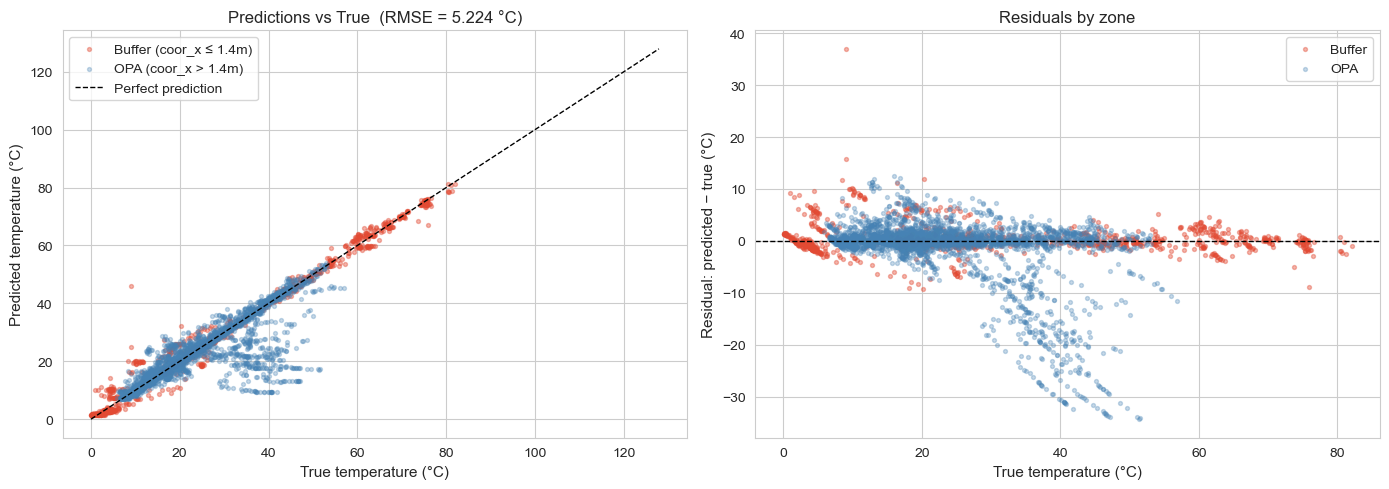

RMSE global : 5.2242
RMSE Buffer : 3.1918
RMSE OPA    : 5.6367


In [38]:
# ----------------------------
# Results visualisation
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = np.random.default_rng(42).choice(len(y_val), size=min(5000, len(y_val)), replace=False)
y_s    = y_val[sample]
p_s    = val_pred[sample]
zone_s = val_part['coor_x'].values[sample] > BUFFER_X  # True = OPA

# Scatter coloré par zone
ax = axes[0]
ax.scatter(y_s[~zone_s], p_s[~zone_s], alpha=0.4, s=8,
           color='#E24A33', label='Buffer (coor_x ≤ 1.4m)')
ax.scatter(y_s[zone_s],  p_s[zone_s],  alpha=0.3, s=8,
           color='steelblue', label='OPA (coor_x > 1.4m)')
lims = [min(y_val.min(), val_pred.min()), max(y_val.max(), val_pred.max())]
ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('True temperature (°C)', fontsize=11)
ax.set_ylabel('Predicted temperature (°C)', fontsize=11)
ax.set_title(f'Predictions vs True  (RMSE = {rmse:.3f} °C)', fontsize=12)
ax.legend(fontsize=10)

# Résidus par zone
ax = axes[1]
residuals = p_s - y_s
ax.scatter(y_s[~zone_s], residuals[~zone_s], alpha=0.4, s=8,
           color='#E24A33', label='Buffer')
ax.scatter(y_s[zone_s],  residuals[zone_s],  alpha=0.3, s=8,
           color='steelblue', label='OPA')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('True temperature (°C)', fontsize=11)
ax.set_ylabel('Residual: predicted − true (°C)', fontsize=11)
ax.set_title('Residuals by zone', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# RMSE par zone
buf_mask = val_part['coor_x'].values > BUFFER_X
rmse_buf = float(np.sqrt(mean_squared_error(y_val[~buf_mask], val_pred[~buf_mask])))
rmse_opa = float(np.sqrt(mean_squared_error(y_val[buf_mask],  val_pred[buf_mask])))
print(f'RMSE global : {rmse:.4f}')
print(f'RMSE Buffer : {rmse_buf:.4f}')
print(f'RMSE OPA    : {rmse_opa:.4f}')

**Left — Predictions vs True:**
- **Buffer (red):** points closely follow the diagonal — strong thermal gradient near the canister makes IDW very accurate.
- **OPA (blue):** more scatter, especially at low temperatures (10–35 °C) where sensors are sparse and gradients are small.
- **Bottom-left cluster (~10–25 °C):** early years of the experiment when all sensors are near ambient (~12 °C) — spatial features carry no discriminating signal, hence the spread.

**Right — Residuals:**
- Residuals are symmetric around 0: no systematic over- or under-prediction.
- Variance increases at low temperatures (hard OPA early-time regime).
- At high temperatures (> 60 °C, Buffer sensors), residuals are near zero — the model is very accurate there.

In [ ]:
# ----------------------------
# Final model on all training data + submission
# ----------------------------
print('Final training on all cleaned data...')

nm_full    = build_neighbor_map(all_train_coords, all_train_coords, K_BROAD)
train_full = compute_hybrid_features(train_cleaned, expand_neighbors(train_cleaned, nm_full, lookup_all))
for col in SPATIAL_FEATURES:
    train_full[col] = train_full[col].fillna(train_full[col].median())

print('  Computing final dT/dt...')
dtdt_full  = build_dtdt_lookup(train_full)
train_full = compute_dtdt_feature(train_full, nm_full, dtdt_full)
train_full['nn_dtdt'] = train_full['nn_dtdt'].fillna(train_full['nn_dtdt'].median())
test_feat['nn_dtdt']  = test_feat['nn_dtdt'].fillna(train_full['nn_dtdt'].median())

print('  Computing final IDW...')
train_full = compute_idw_feature(train_full, all_train_coords, all_train_coords, train_full)
train_full['idw_temp'] = train_full['idw_temp'].fillna(train_full['idw_temp'].median())
test_feat['idw_temp']  = test_feat['idw_temp'].fillna(train_full['idw_temp'].median())

final_model = HistGradientBoostingRegressor(**MODEL_PARAMS)
final_model.fit(train_full[features], train_full[TARGET])

test_f = test_feat[features].copy()
if test_f.isna().any().any():
    test_f = test_f.fillna(train_full[features].median())

test_pred = final_model.predict(test_f)

# Save submission
id_col = next((c for c in ['id', 'Id', 'ID'] if c in test_feat.columns), None)
sub = pd.DataFrame({
    (id_col if id_col else 'Id'): (test_feat[id_col].to_numpy() if id_col else np.arange(len(test_feat))),
    TARGET: test_pred,
})
sub_path = SUBMISSIONS_DIR / 'best_submission.csv'
sub.to_csv(sub_path, index=False)

joblib.dump({'model': final_model, 'features': features}, REPO_ROOT / 'models' / 'best_model.joblib')

print(f'\nSubmission saved: {sub_path}')
print(f'Predictions — min: {test_pred.min():.2f} °C | max: {test_pred.max():.2f} °C | mean: {test_pred.mean():.2f} °C')
print(f'\nKaggle score: 3.22')

Final training on all cleaned data...
  Computing final dT/dt...
  Computing final IDW...

Submission saved: C:\Users\abill\OneDrive\מסמכים\GitHub\final_project_ML\submissions\best_submission.csv
Predictions — min: -0.04 °C | max: 81.51 °C | mean: 23.71 °C

Kaggle score (Kaggle v12): 3.22
